# Does Negative National Economic Perception Cause Voters to Defect from the Incumbent Party? Evidence from the 2022 U.S. Midterm Elections

**Course:** Foundations of Data Science (NYU, Spring 2026)

**Group Members:** Akarsh Malik, Harshal Pimpalshende, Shyamak Danavale

**Dataset:** Cooperative Election Study (CES) 2022 Common Content (Schaffner, Ansolabehere, & Shih 2023; Harvard Dataverse)

## 1. Introduction

### 1.1. The Question / Estimand

**Does negative national economic perception cause voters to be less likely to vote for the incumbent party’s candidate, and does this effect hold after accounting for partisan identity?**

This question is examined in the context of the 2022 U.S. midterm elections, during which the CES data was collected. The period was marked by high inflation (around 8–9%), rising interest rates, and widespread concern about the cost of living, leading to meaningful variation in how voters perceived the national economy. Since the Democratic Party held the presidency and Congress at the time, negative economic perceptions could plausibly reduce support for Democratic candidates.

However, partisan identity is a key confounder, as it influences both how individuals perceive the economy and how they vote. Voters often interpret the same economic conditions differently based on party alignment. Therefore, the estimand of interest is the causal effect of economic perception on vote choice, specifically how the probability of voting for the incumbent party changes as perceptions worsen, holding party identification constant.

### 1.2. Data Description

*   **Source:** Cooperative Election Study (CES) 2022 Common Content. Harvard Dataverse, [https://doi.org/10.7910/DVN/PR4L8P](https://doi.org/10.7910/DVN/PR4L8P)
*   **Unit of observation:** One row per validated U.S. adult survey respondent ($N \approx 60,000$, of which $\approx 35,000$ respondents provided their specific vote choice).
*   **Mode:** YouGov-administered online panel, post-stratified to approximate a national probability sample using the `commonpostweight`.

We use the Cooperative Election Study (CES) 2022 Common Content, a large, nationally representative survey conducted during the Fall 2022 U.S. midterm elections (with both pre- and post-election waves). The dataset is well-suited for our analysis due to its timing during a period of high inflation and economic uncertainty, which generates meaningful variation in voters’ retrospective economic perceptions.

The CES includes all key variables required for our study: a retrospective national economic perception measure (CC22_302) used as the treatment, a validated/self-reported House vote choice variable (CC22_367 / CC22_412) used as the outcome, and a clean three-category party identification variable (pid3) used to adjust for confounding. The large sample size allows for reliable estimation of effects within party strata with low Monte Carlo error, while validated vote records help reduce self-report bias.

## 2. Causal Model

### 2.1. Variables

We deliberately use mnemonic single-letter symbols (not `T`, `Y`, `Z`) so the variable names match the dataset.

| Role        | Symbol | Source variable             | Description                                                                                                | Levels                                                                 |
|:------------|:------:|:----------------------------|:-----------------------------------------------------------------------------------------------------------|:-----------------------------------------------------------------------|
| Treatment   |  $E$   | `CC22_302` (Econ)           | Retrospective national-economy perception over the past year                                                | 1 = Much Better, 2 = Better, 3 = Same, 4 = Worse, 5 = Much Worse       |
| Outcome     |  $V$   | `CC22_367` + cand party     | Voted for the **incumbent (Democratic) party's** House candidate in 2022                                    | 0 = No, 1 = Yes (Bernoulli)                                            |
| Confound    |  $P$   | `pid3` (Party ID)           | Self-reported partisan identification                                                                       | 1 = Democrat, 2 = Independent, 3 = Republican

### 2.2. Assumed Causal Relationships

The DAG encodes three claims:

1.  $P \rightarrow E$: Party identification colors how voters perceive the national economy (Republicans were more likely to view the Biden-era economy negatively in 2022; Democrats more positively). This is the classic “partisan-perception” channel (Bartels 2002; Bisgaard 2015).
2.  $P \rightarrow V$: Party identification is the strongest single predictor of vote choice (Campbell et al. 1960; Bartels 2000).
3.  $E \rightarrow V$: The causal pathway of interest — retrospective economic perceptions influence the decision to reward or punish the incumbent party.

Because $P$ is a common cause of both $E$ and $V$, it is a classical confounder (a **Fork**). The backdoor path $E \leftarrow P \rightarrow V$ must be blocked to identify the direct causal effect of $E$ on $V$.

This structure is well supported in the political science literature. Party identification is a well-established driver of both political perception and behavior. Classic work such as *The American Voter* (Campbell, Converse, Miller, & Stokes, 1960) shows that party ID structures political attitudes. Bartels (2002), in “Beyond the Running Tally: Partisan Bias in Political Perceptions,” demonstrates that partisans interpret identical economic conditions differently. Fiorina (1981), in *Retrospective Voting in American National Elections*, establishes that economic evaluations shape incumbent voting decisions. Together, this literature justifies treating party identification as a confounder affecting both perception and vote choice.

<img src="../reports/figures/dag.png" width="700" height="500">


## 3. Statistical Model

The outcome $V_i \in \{0,1\}$ is a binary indicator of whether a voter chose the incumbent party, so we use a Bernoulli likelihood with a logit link. Since both the treatment $E$ (economic perception) and the confound $P$ (party identification) are categorical, we follow the approach used in lectures (especially the UC Berkeley admissions example) and use index-based encoding instead of dummy variables.

We model this using a full interaction between economic perception and party ID by defining a $5 \times 3$ matrix of parameters:

$$
\begin{aligned}
V_i &\sim \text{Bernoulli}(p_i) \\
\text{logit}(p_i) &= \alpha_{E[i], P[i]} \\
\alpha_{e,p} &\sim \text{Normal}(0, 1.5), \quad e \in \{1,\dots,5\}, p \in \{1,2,3\}
\end{aligned}
$$

Here, each $\alpha_{e,p}$ represents the log-odds of voting for the incumbent party for a specific combination of economic perception and party identification. This means we estimate separate probabilities for each $(E, P)$ group instead of assuming the same effect across groups.

This setup is useful because it directly handles the confound $P$ by stratifying on it. Once we have these group-level estimates, we can compute the overall causal effect by post-stratifying, i.e., averaging across party groups using their observed distribution. It also allows us to look at how the effect changes across all five levels of economic perception, giving a more detailed relationship rather than just comparing two groups.

### 3.1. Justification of Priors

We chose $\alpha_{e,p} \sim \text{Normal}(0, 1.5)$ on the **log-odds** scale based on domain knowledge about voting behavior.

**Domain knowledge.**
In U.S. elections, even within specific subgroups (defined by economic perception and party identification), voting probabilities are rarely extreme. It is unrealistic for any subgroup to have near-certain probabilities (close to 0 or 1) of voting for the incumbent party. Instead, most groups tend to fall within a moderate range, roughly between $0.05$ and $0.95$. On the log-odds scale, this corresponds approximately to the interval $[-3, +3]$. A $\text{Normal}(0, 1.5)$ prior places most of its mass within this range, ensuring that predicted probabilities remain realistic while still allowing meaningful variation across groups.



**Substantive expectations about voting.**
Political science research shows that voting behavior is influenced by multiple factors (e.g., party identification, economic perceptions, candidate characteristics), meaning that no single factor fully determines the outcome. Even strong partisan groups do not exhibit perfectly deterministic behavior. Therefore, the prior should allow for strong effects (e.g., clear differences across party groups) but avoid implying that any group will vote with certainty. The $\text{Normal}(0, 1.5)$ prior reflects this by permitting moderate to strong differences in log-odds while still regularizing extreme values.

Overall, this prior represents a balance: it incorporates realistic expectations about voter behavior without imposing overly strong assumptions, allowing the data to determine the final estimates.

### 3.2. Justification of Outcome Distribution

The outcome is a single binary trial per respondent (voted for the incumbent-party House candidate, or not), so $V_i\sim\text{Bernoulli}(p_i)$ is unique for a single 0/1 trial. The logit link maps the $(0,1)$ probability scale to the unconstrained real line, allowing the linear index $\alpha_{e,p}$ to live on $\mathbb{R}$ without artificial truncation. No alternative distribution (Normal, Poisson, etc.) is appropriate for unbounded binary data.

### 3.3. Handling the Confound

Stratifying by $(E, P)$ closes the backdoor path $E \leftarrow P \rightarrow V$, ensuring that the effect of economic perception is estimated while holding party identification constant. By estimating separate parameters $\alpha_{e,p}$, we compare voters with different economic perceptions within the same party group, removing confounding. The overall causal effect is then obtained by averaging these stratum-specific effects over the distribution of party identification.

## 4. Model Validation on Simulated Data

*(**Hint:** Use `arviz.plot_posterior()` with the `ref_val` parameter set to your fixed simulation parameter values to check how well your model estimates them. )*

/opt/homebrew/Caskroom/miniconda/base/envs/fds-project/lib/python3.10/site-packages/arviz/rcparams.py:345: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


Simulated N = 8,500
Cell counts:
[[ 400  200  100]
 [ 600  400  200]
 [ 700  800  600]
 [ 500  700 1000]
 [ 300  600 1400]]


Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 5 seconds.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"alpha[Much Better, Democrat]",3.06,0.24,2.69,3.43,0.0,0.0,8444.0,3168.0,1.00
"alpha[Much Better, Independent]",1.47,0.18,1.18,1.77,0.0,0.0,7928.0,2750.0,1.00
"alpha[Much Better, Republican]",-0.93,0.22,-1.31,-0.59,0.0,0.0,9306.0,2960.0,1.00
"alpha[Better, Democrat]",2.34,0.14,2.13,2.58,0.0,0.0,10443.0,2987.0,1.00
"alpha[Better, Independent]",0.67,0.10,0.50,0.83,0.0,0.0,10475.0,3147.0,1.00
"alpha[Better, Republican]",-1.50,0.18,-1.79,-1.21,0.0,0.0,8988.0,2794.0,1.00
"alpha[Same, Democrat]",1.96,0.11,1.77,2.13,0.0,0.0,8631.0,3036.0,1.00
"alpha[Same, Independent]",0.20,0.07,0.09,0.31,0.0,0.0,8247.0,3090.0,1.00
"alpha[Same, Republican]",-2.03,0.13,-2.23,-1.82,0.0,0.0,9774.0,2612.0,1.00
"alpha[Worse, Democrat]",1.43,0.11,1.26,1.61,0.0,0.0,9959.0,2839.0,1.00


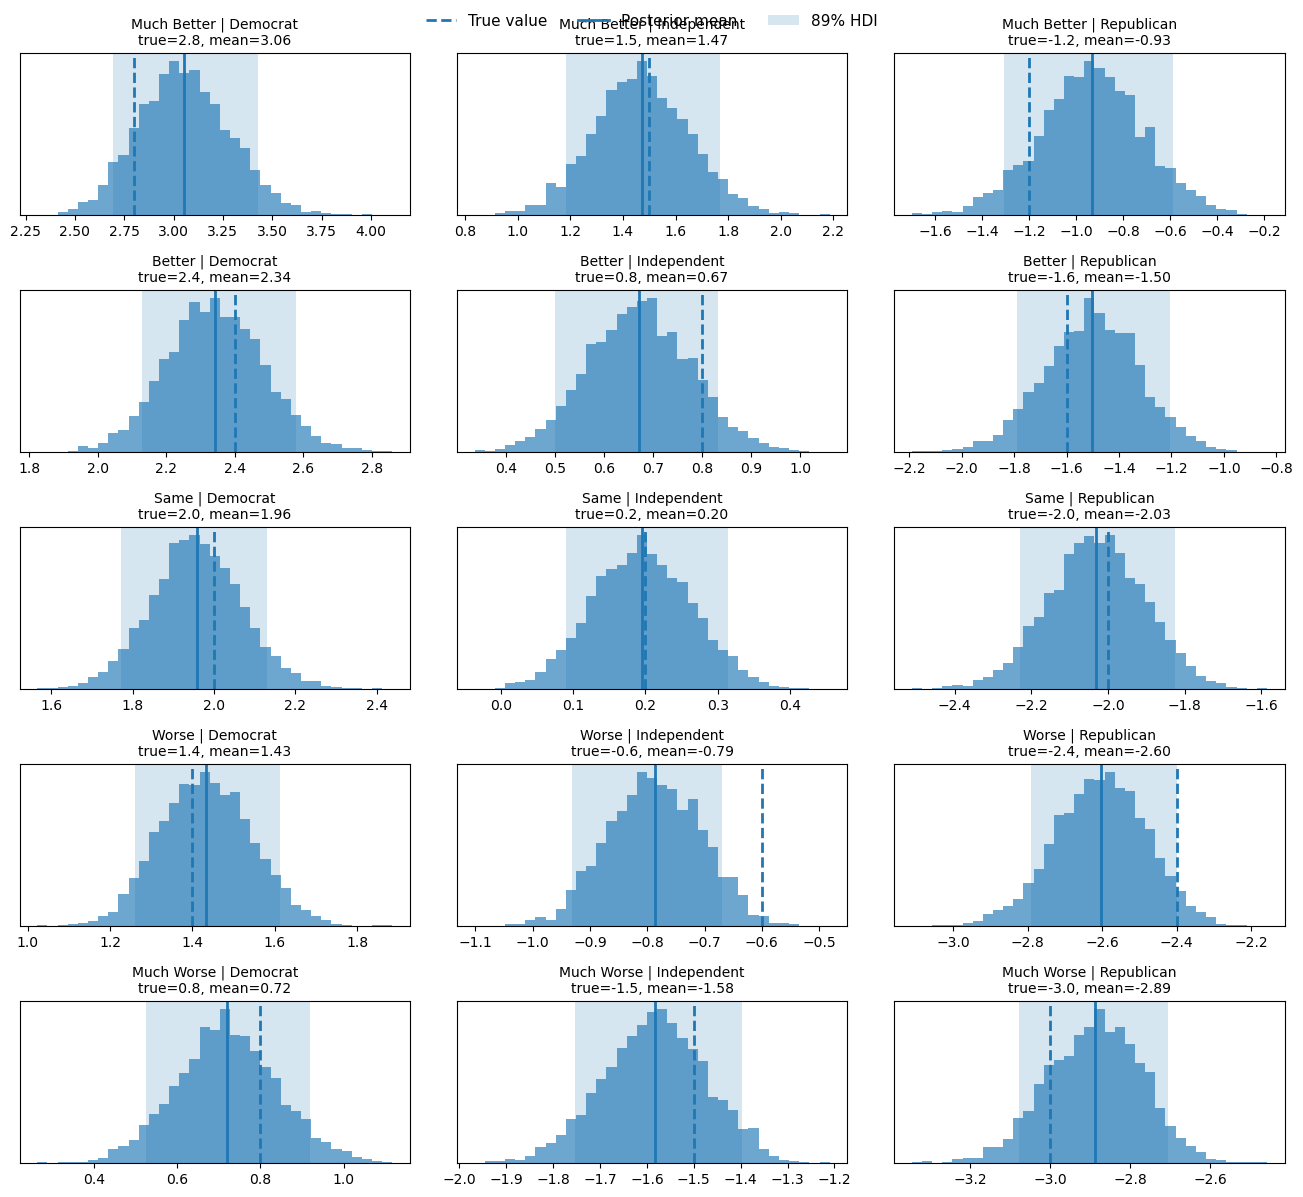

In [2]:
# 1. Define fixed parameter values (e.g., alpha_sim = 0.3, beta_sim = 0.5, etc)

import numpy as np
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

az.rcParams["stats.hdi_prob"] = 0.89

rng = np.random.default_rng(42)

# True parameter values on the log-odds scale
# Rows = economic perception levels
# Columns = party ID groups
ALPHA_TRUE = np.array([
    [ 2.8,  1.5, -1.2],   # Much Better
    [ 2.4,  0.8, -1.6],   # Somewhat Better
    [ 2.0,  0.2, -2.0],   # Same
    [ 1.4, -0.6, -2.4],   # Somewhat Worse
    [ 0.8, -1.5, -3.0],   # Much Worse
])

econ_labels = ["Much Better", "Better", "Same", "Worse", "Much Worse"]
party_labels = ["Democrat", "Independent", "Republican"]

# Number of observations in each (economic perception, party ID) cell
N_PER_CELL = np.array([
    [400, 200, 100],
    [600, 400, 200],
    [700, 800, 600],
    [500, 700, 1000],
    [300, 600, 1400],
])


# 2. Simulate data based on your causal/statistical model using these fixed values

E_idx_sim = []
P_idx_sim = []
V_sim = []

for e in range(5):
    for p in range(3):
        n = N_PER_CELL[e, p]
        prob = 1 / (1 + np.exp(-ALPHA_TRUE[e, p]))

        votes = rng.binomial(n=1, p=prob, size=n)

        E_idx_sim.extend([e] * n)
        P_idx_sim.extend([p] * n)
        V_sim.extend(votes)

E_idx_sim = np.array(E_idx_sim, dtype=int)
P_idx_sim = np.array(P_idx_sim, dtype=int)
V_sim = np.array(V_sim, dtype=int)

print(f"Simulated N = {len(V_sim):,}")
print("Cell counts:")
print(N_PER_CELL)


# 3. Run your computational model (using PyMC) on this simulated data

coords_sim = {
    "econ": econ_labels,
    "party": party_labels,
    "obs": np.arange(len(V_sim))
}

with pm.Model(coords=coords_sim) as sim_model:

    E_data = pm.Data("E_idx", E_idx_sim, dims="obs")
    P_data = pm.Data("P_idx", P_idx_sim, dims="obs")

    # Same model structure as final model
    alpha = pm.Normal(
        "alpha",
        mu=0,
        sigma=1.5,
        dims=("econ", "party")
    )

    logit_p = alpha[E_data, P_data]

    V_obs = pm.Bernoulli(
        "V",
        logit_p=logit_p,
        observed=V_sim,
        dims="obs"
    )

    sim_idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        cores=4,
        target_accept=0.9,
        random_seed=42
    )


# 4. Check how well your model estimates the parameter values. 
# Do the posterior estimates from the model capture the true values you defined?

sim_summary = az.summary(
    sim_idata,
    var_names=["alpha"],
    hdi_prob=0.89
)

display(sim_summary.round(2))


# ----------------------------
# Clean parameter recovery plot
# ----------------------------

posterior_alpha = sim_idata.posterior["alpha"]

fig, axes = plt.subplots(
    nrows=5,
    ncols=3,
    figsize=(13, 12),
    sharex=False
)

for e in range(5):
    for p in range(3):

        ax = axes[e, p]

        samples = posterior_alpha.sel(
            econ=econ_labels[e],
            party=party_labels[p]
        ).values.flatten()

        true_val = ALPHA_TRUE[e, p]
        hdi = az.hdi(samples, hdi_prob=0.89)

        ax.hist(samples, bins=35, density=True, alpha=0.65)

        # True value
        ax.axvline(
            true_val,
            linestyle="--",
            linewidth=2,
            label="True value"
        )

        # Posterior mean
        ax.axvline(
            samples.mean(),
            linestyle="-",
            linewidth=2,
            label="Posterior mean"
        )

        # 89% HDI
        ax.axvspan(
            hdi[0],
            hdi[1],
            alpha=0.18,
            label="89% HDI"
        )

        ax.set_title(
            f"{econ_labels[e]} | {party_labels[p]}\n"
            f"true={true_val:.1f}, mean={samples.mean():.2f}",
            fontsize=10
        )

        ax.set_yticks([])

# One legend for whole figure
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=3,
    frameon=False,
    fontsize=11
)

plt.tight_layout()
plt.show()

### Interpretation of results

The model successfully recovers the true parameter values used to generate the data. Across all $(E, P)$ cells, the posterior means are close to the true log-odds values, and the true parameters lie within the 89% highest density intervals (HDIs). This indicates that the model is able to accurately estimate both the direction and magnitude of effects.

Uncertainty behaves as expected: cells with larger sample sizes have tighter posterior distributions, while smaller cells show slightly wider intervals, but still capture the true values. The recovery plots show strong alignment between the true values and the centers of the posterior distributions, with no evidence of systematic bias.

Additionally, convergence diagnostics such as $\hat{R} \approx 1$ and high effective sample sizes confirm that the sampling is stable and reliable. Overall, these results demonstrate that the model is correctly specified and capable of recovering known parameters, providing confidence in applying it to the real dataset.

## 5. Data Preparation (Real Data)

*(Load the real dataset. Perform any necessary cleaning, scaling, or transformations. )*

In [3]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az

az.rcParams["stats.hdi_prob"] = 0.89

# ----------------------------
# 1. Load and clean data
# ----------------------------

data = pd.read_csv("../data/raw/raw.csv", low_memory=False)

cols = [
    "CC22_302", "CC22_412", "pid3",
    "HouseCand1Party", "HouseCand2Party", "HouseCand3Party",
    "HouseCand4Party", "HouseCand5Party", "HouseCand6Party",
    "HouseCand7Party", "HouseCand8Party"
]

df = data[cols].dropna(subset=["CC22_302", "CC22_412", "pid3"])

# Valid economic perception values: 1–5 only
df = df[df["CC22_302"].isin([1, 2, 3, 4, 5])]

# Valid House vote values: candidate choices 1–8 only
df = df[df["CC22_412"].isin([1, 2, 3, 4, 5, 6, 7, 8])]

# Map voted candidate to Democrat = 1, otherwise = 0
def map_voted_dem(row):
    vote = row["CC22_412"]
    party_col = f"HouseCand{int(vote)}Party"
    party = row[party_col]

    if party == "Democratic":
        return 1
    elif pd.notna(party):
        return 0
    return np.nan

df["voted_dem_house"] = df.apply(map_voted_dem, axis=1)
df = df.dropna(subset=["voted_dem_house"])

# Map party ID
df["party_id"] = df["pid3"].map({
    1: "Democrat",
    2: "Republican",
    3: "Independent",
    4: "Other",
    5: "Not sure"
})

# Keep only main party groups
df = df[df["party_id"].isin(["Democrat", "Republican", "Independent"])]

# Rename treatment column
df = df.rename(columns={"CC22_302": "econ_perception"})
df = df[["econ_perception", "voted_dem_house", "party_id"]].copy()

# ----------------------------
# 2. Create indices for model
# ----------------------------

ECON_LEVELS = ["Much Better", "Somewhat Better", "Same", "Somewhat Worse", "Much Worse"]
PARTY_LEVELS = ["Democrat", "Independent", "Republican"]

econ_map = {
    1: 0,  # Much Better
    2: 1,  # Somewhat Better
    3: 2,  # Same
    4: 3,  # Somewhat Worse
    5: 4   # Much Worse
}

party_map = {
    "Democrat": 0,
    "Independent": 1,
    "Republican": 2
}

df["E_idx"] = df["econ_perception"].map(econ_map).astype(int)
df["P_idx"] = df["party_id"].map(party_map).astype(int)
df["V"] = df["voted_dem_house"].astype(int)

E_obs = df["E_idx"].to_numpy()
P_obs = df["P_idx"].to_numpy()
V_obs = df["V"].to_numpy()

# ----------------------------
# 3. Sanity checks
# ----------------------------

print("Shape:", df.shape)

print("\nVote distribution:")
print(df["V"].value_counts())

print("\nParty distribution:")
print(df["party_id"].value_counts())

print("\nEcon perception distribution:")
print(df["econ_perception"].value_counts().sort_index())

print("\nCell counts by econ perception and party:")
print(pd.crosstab(df["econ_perception"], df["party_id"]))


/opt/homebrew/Caskroom/miniconda/base/envs/fds-project/lib/python3.10/site-packages/arviz/rcparams.py:345: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


Shape: (35628, 6)

Vote distribution:
V
1    20025
0    15603
Name: count, dtype: int64

Party distribution:
party_id
Democrat       15445
Republican     10645
Independent     9538
Name: count, dtype: int64

Econ perception distribution:
econ_perception
1.0     1273
2.0     4556
3.0     4266
4.0     9852
5.0    15681
Name: count, dtype: int64

Cell counts by econ perception and party:
party_id         Democrat  Independent  Republican
econ_perception                                   
1.0                   928          222         123
2.0                  3496          885         175
3.0                  2880         1099         287
4.0                  5739         2575        1538
5.0                  2402         4757        8522


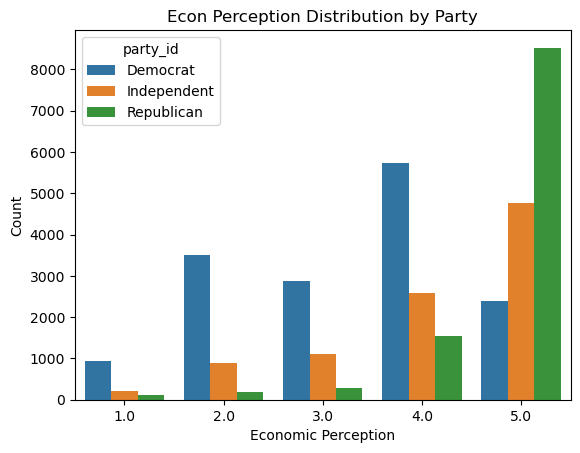

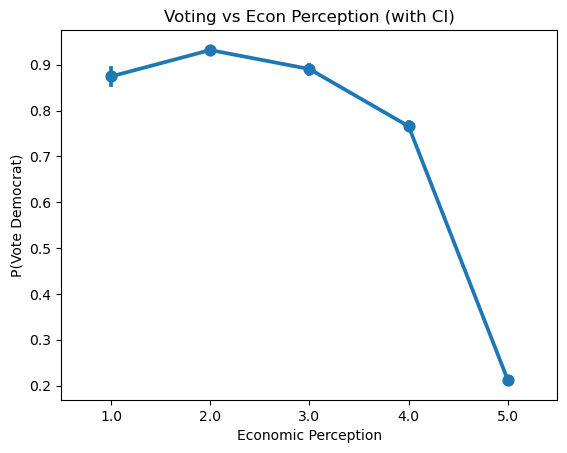

In [4]:
import seaborn as sns
# ---------- Plot 1: Distribution ----------
plt.figure()
sns.countplot(data=df, x="econ_perception", hue="party_id")
plt.xlabel("Economic Perception")
plt.ylabel("Count")
plt.title("Econ Perception Distribution by Party")
plt.savefig("../reports/figures/econ_distribution_by_party.png", dpi=300, bbox_inches="tight")
plt.show()

# ---------- Plot 2: With confidence intervals ----------
plt.figure()
sns.pointplot(data=df, x="econ_perception", y="voted_dem_house", errorbar="ci")
plt.ylabel("P(Vote Democrat)")
plt.xlabel("Economic Perception")
plt.title("Voting vs Econ Perception (with CI)")
plt.savefig("../reports/figures/econ_vs_vote_ci.png", dpi=300, bbox_inches="tight")
plt.show()

## 6. Posterior Model (Analysis on Real Data)


### 6.1. Computational Model Definition and Sampling


In [5]:
import numpy as np
import pymc as pm
import arviz as az

COORDS = {
    "econ": ECON_LEVELS,
    "party": PARTY_LEVELS,
    "obs": np.arange(V_obs.size),
}

with pm.Model(coords=COORDS) as econ_vote_model:

    E_data = pm.Data("E_idx", E_obs, dims="obs")
    P_data = pm.Data("P_idx", P_obs, dims="obs")

    # Full interaction: one log-odds parameter for each (economic perception, party ID) cell
    alpha = pm.Normal(
        "alpha",
        mu=0.0,
        sigma=1.5,
        dims=("econ", "party")
    )

    logit_p = alpha[E_data, P_data]

    p = pm.Deterministic(
        "p",
        pm.math.sigmoid(logit_p),
        dims="obs"
    )

    pm.Bernoulli(
        "V",
        logit_p=logit_p,
        observed=V_obs,
        dims="obs"
    )

    idata = pm.sample(
        draws=1000,
        tune=1000,
        chains=4,
        cores=4,
        target_accept=0.9,
        random_seed=20260501,
        progressbar=True,
        idata_kwargs={"log_likelihood": True}
    )

print("Sampling complete.")

# ----------------------------
# 5. Posterior summary
# ----------------------------

az.summary(
    idata,
    var_names=["alpha"],
    hdi_prob=0.89
)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 23 seconds.


Sampling complete.


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"alpha[Much Better, Democrat]",3.506,0.191,3.185,3.795,0.002,0.004,8066.0,2529.0,1.00
"alpha[Much Better, Independent]",1.600,0.183,1.323,1.909,0.002,0.003,9732.0,2997.0,1.01
"alpha[Much Better, Republican]",-1.302,0.214,-1.632,-0.952,0.002,0.004,8642.0,2731.0,1.00
"alpha[Somewhat Better, Democrat]",3.502,0.101,3.336,3.655,0.001,0.002,7676.0,3032.0,1.00
"alpha[Somewhat Better, Independent]",2.148,0.109,1.982,2.330,0.001,0.002,8864.0,2954.0,1.00
"alpha[Somewhat Better, Republican]",-0.700,0.155,-0.948,-0.456,0.002,0.003,9099.0,3269.0,1.00
"alpha[Same, Democrat]",3.421,0.106,3.238,3.576,0.001,0.002,8168.0,2815.0,1.00
"alpha[Same, Independent]",1.827,0.090,1.692,1.979,0.001,0.002,10212.0,2488.0,1.00
"alpha[Same, Republican]",-1.283,0.145,-1.516,-1.050,0.002,0.003,7106.0,2405.0,1.00
"alpha[Somewhat Worse, Democrat]",3.186,0.068,3.073,3.286,0.001,0.001,10965.0,2554.0,1.00


### 6.2. Model Diagnostics

*(Use built-in diagnostics to assess the quality of the posterior samples (e.g., trace plots, r-hat, effective sample size). )*

/opt/homebrew/Caskroom/miniconda/base/envs/fds-project/lib/python3.10/site-packages/arviz/rcparams.py:345: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


,mean,sd,hdi_5.5%,hdi_94.5%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
"alpha[Much Better, Democrat]",3.506,0.191,3.185,3.795,0.002,0.004,8066.0,2529.0,1.00
"alpha[Much Better, Independent]",1.600,0.183,1.323,1.909,0.002,0.003,9732.0,2997.0,1.01
"alpha[Much Better, Republican]",-1.302,0.214,-1.632,-0.952,0.002,0.004,8642.0,2731.0,1.00
"alpha[Somewhat Better, Democrat]",3.502,0.101,3.336,3.655,0.001,0.002,7676.0,3032.0,1.00
"alpha[Somewhat Better, Independent]",2.148,0.109,1.982,2.330,0.001,0.002,8864.0,2954.0,1.00
"alpha[Somewhat Better, Republican]",-0.700,0.155,-0.948,-0.456,0.002,0.003,9099.0,3269.0,1.00
"alpha[Same, Democrat]",3.421,0.106,3.238,3.576,0.001,0.002,8168.0,2815.0,1.00
"alpha[Same, Independent]",1.827,0.090,1.692,1.979,0.001,0.002,10212.0,2488.0,1.00
"alpha[Same, Republican]",-1.283,0.145,-1.516,-1.050,0.002,0.003,7106.0,2405.0,1.00
"alpha[Somewhat Worse, Democrat]",3.186,0.068,3.073,3.286,0.001,0.001,10965.0,2554.0,1.00


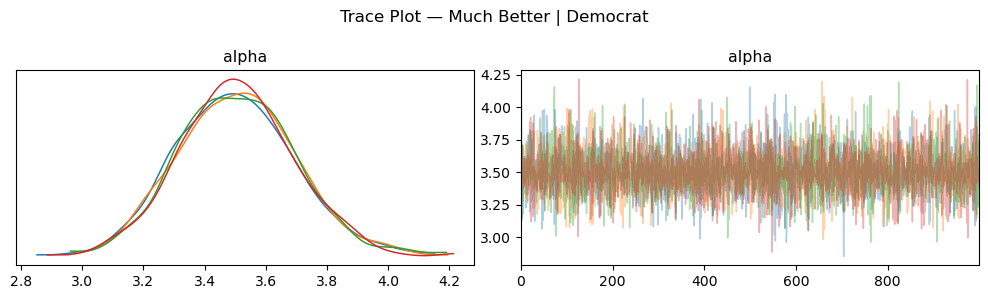

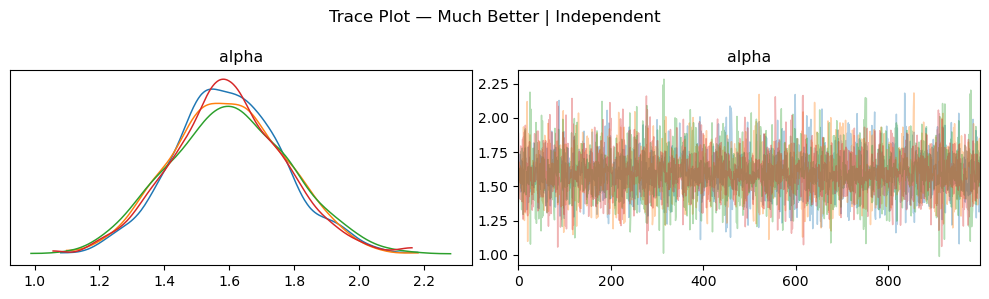

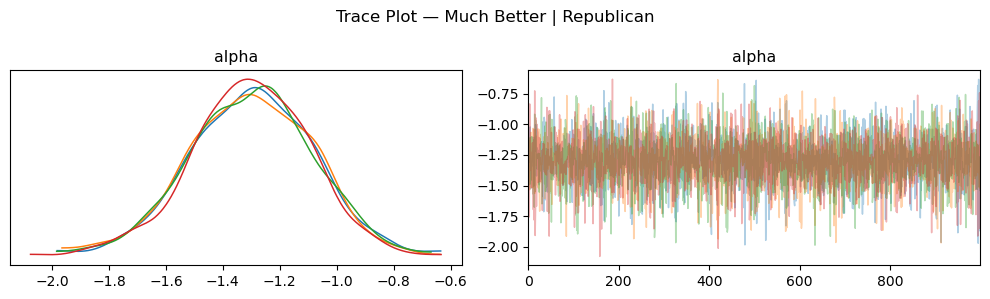

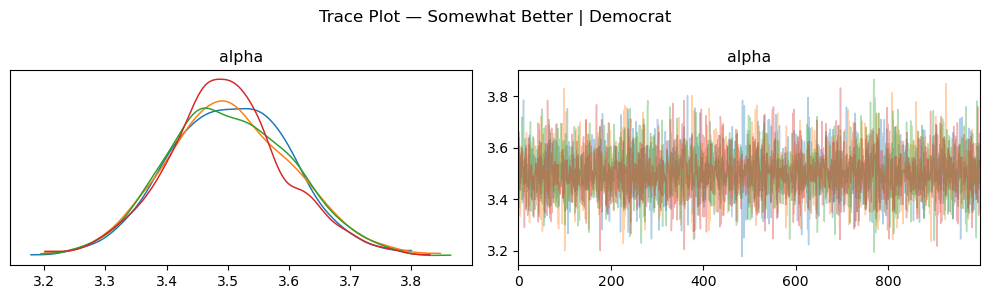

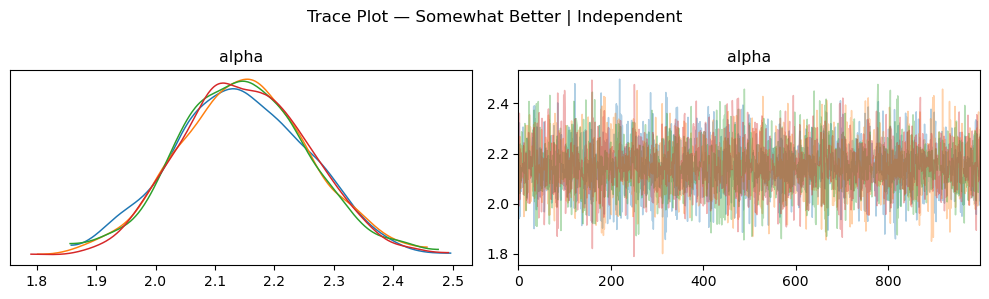

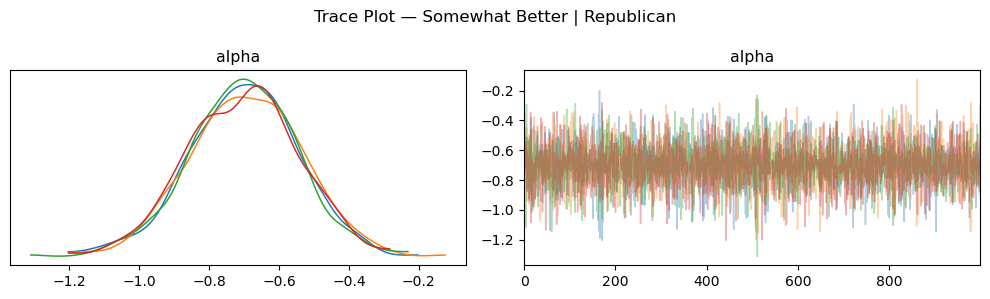

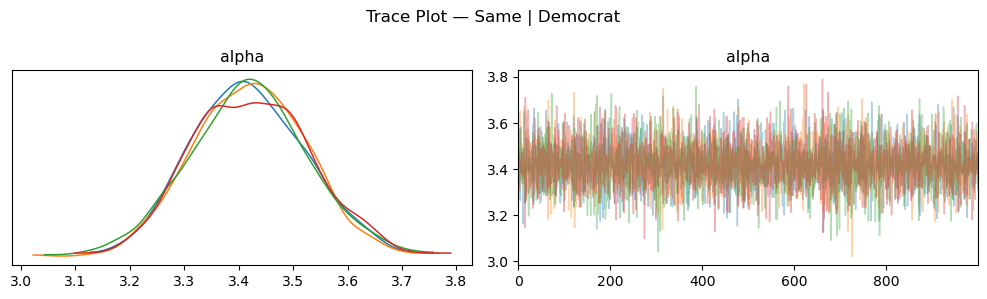

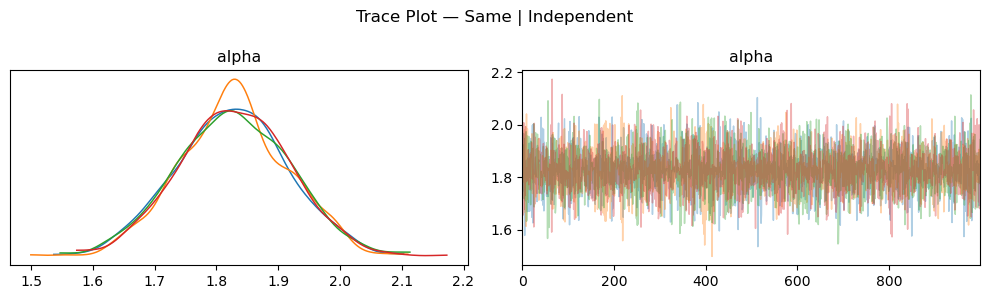

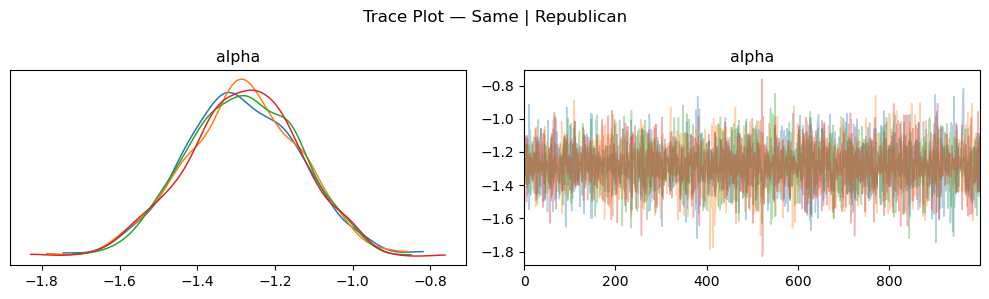

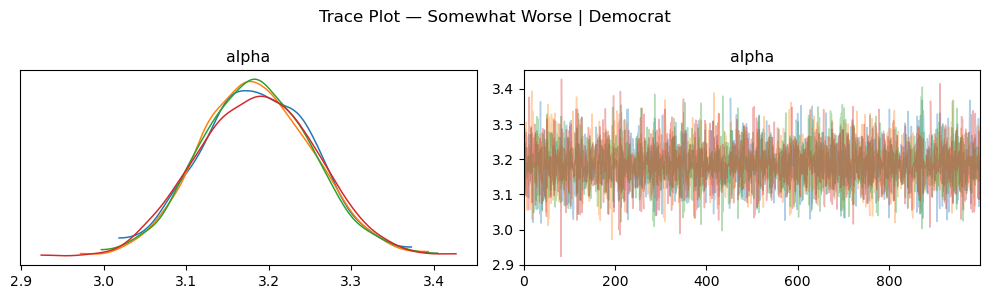

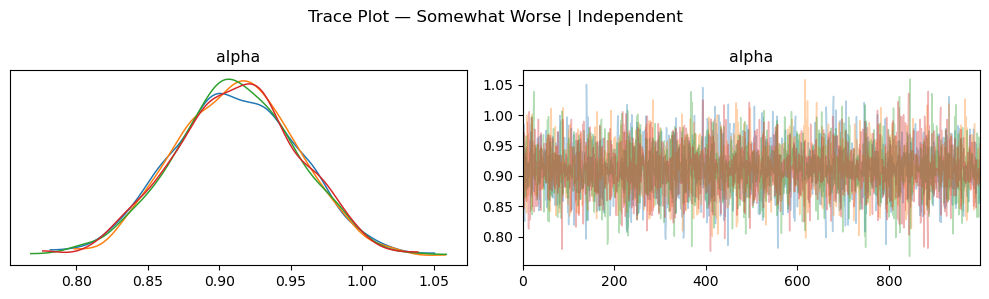

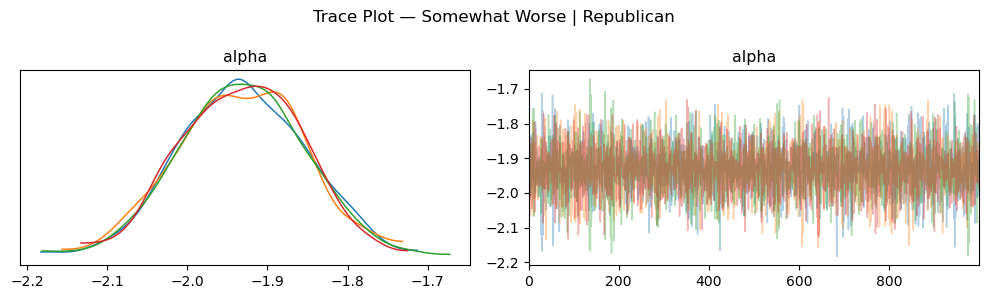

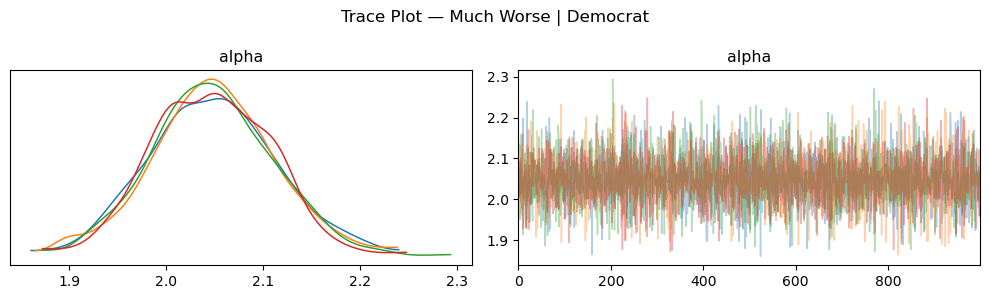

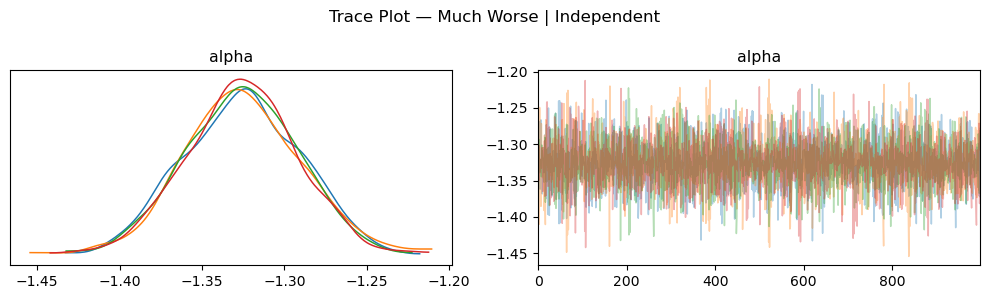

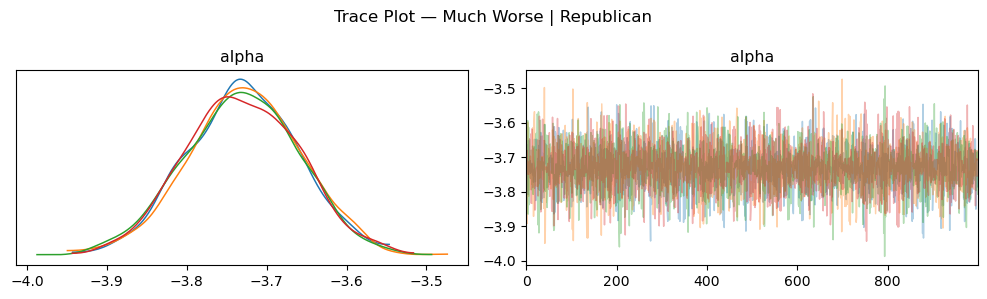

R-hat values:


<xarray.Dataset> Size: 552B
Dimensions:  (econ: 5, party: 3)
Coordinates:
  * econ     (econ) <U15 300B 'Much Better' 'Somewhat Better' ... 'Much Worse'
  * party    (party) <U11 132B 'Democrat' 'Independent' 'Republican'
Data variables:
    alpha    (econ, party) float64 120B 0.9997 1.005 1.002 ... 1.001 1.0 1.002

Effective Sample Size:


<xarray.Dataset> Size: 552B
Dimensions:  (econ: 5, party: 3)
Coordinates:
  * econ     (econ) <U15 300B 'Much Better' 'Somewhat Better' ... 'Much Worse'
  * party    (party) <U11 132B 'Democrat' 'Independent' 'Republican'
Data variables:
    alpha    (econ, party) float64 120B 8.066e+03 9.732e+03 ... 9.37e+03

In [6]:
import matplotlib.pyplot as plt
import arviz as az
import numpy as np

az.rcParams["stats.hdi_prob"] = 0.89

# Posterior summary
summary_table = az.summary(
    idata,
    var_names=["alpha"],
    hdi_prob=0.89
)
display(summary_table)

# Clean trace plots: one parameter at a time
econ_levels = idata.posterior.coords["econ"].values
party_levels = idata.posterior.coords["party"].values

for e in econ_levels:
    for p in party_levels:
        fig, axes = plt.subplots(1, 2, figsize=(10, 3))

        az.plot_trace(
            idata,
            var_names=["alpha"],
            coords={"econ": e, "party": p},
            axes=axes.reshape(1, 2),
            compact=False
        )

        fig.suptitle(f"Trace Plot — {e} | {p}", fontsize=12)
        plt.tight_layout()
        plt.show()

# R-hat
rhat_values = az.rhat(
    idata,
    var_names=["alpha"]
)

print("R-hat values:")
display(rhat_values)

# ESS
ess_values = az.ess(
    idata,
    var_names=["alpha"]
)

print("Effective Sample Size:")
display(ess_values)

### **6.2. Model Diagnostics — Discussion**

The diagnostics indicate that the model has converged well and produced high-quality posterior samples. Across all parameters, the $\hat{R}$ values are essentially **1.00**, which suggests that all chains have mixed properly and reached the same stationary distribution. There is no evidence of divergence or non-convergence.

The trace plots further support this: the chains overlap closely and form stable “caterpillar”-like patterns with no visible trends or drift, indicating good mixing and stationarity. The posterior density plots are smooth and unimodal, which is consistent with well-behaved posterior distributions.

Additionally, the effective sample sizes (ESS) are very high for all parameters, meaning that the sampler has generated a large number of effectively independent samples. This leads to precise posterior estimates with low Monte Carlo error.

Overall, the diagnostics confirm that the sampling process is reliable, and the posterior estimates can be trusted for inference.

## 7. Posterior Predictive Checks

*(Visually compare your model's posterior predictions to the observed data. )*

*(The plot(s) in this section should include: )*
* *The observed data*
* *The posterior mean*
* *The uncertainty of the posterior mean (e.g., 89% HDI)*
* *The uncertainty of posterior predictions (e.g., 89% HDI)*

/opt/homebrew/Caskroom/miniconda/base/envs/fds-project/lib/python3.10/site-packages/arviz/rcparams.py:345: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(
Sampling: [V]


Output()

,econ_idx,econ,party_idx,party,observed,posterior_mean,posterior_mean_hdi_low,posterior_mean_hdi_high,posterior_pred_hdi_low,posterior_pred_hdi_high
0,0,Much Better,0,Democrat,0.971983,0.970365,0.962755,0.979858,0.959052,0.982759
1,0,Much Better,1,Independent,0.833333,0.830426,0.790531,0.871577,0.774775,0.882883
2,0,Much Better,2,Republican,0.211382,0.215963,0.157016,0.269983,0.130081,0.292683
3,1,Somewhat Better,0,Democrat,0.971110,0.970623,0.966031,0.975096,0.964245,0.976831
4,1,Somewhat Better,1,Independent,0.896045,0.895020,0.878995,0.911368,0.871186,0.916384
5,1,Somewhat Better,2,Republican,0.331429,0.332610,0.279366,0.387927,0.257143,0.411429
6,2,Same,0,Democrat,0.968750,0.968180,0.963136,0.973518,0.960417,0.974653
7,2,Same,1,Independent,0.861692,0.861077,0.844430,0.878599,0.837125,0.883530
8,2,Same,2,Republican,0.216028,0.218035,0.179034,0.258151,0.167247,0.278746
9,3,Somewhat Worse,0,Democrat,0.960446,0.960222,0.956076,0.964214,0.954347,0.966022


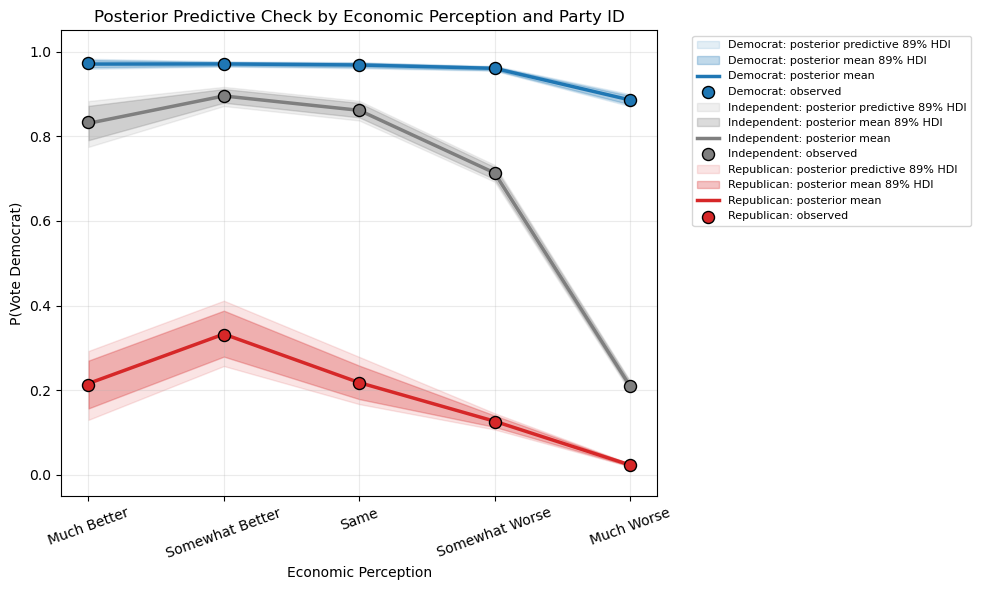

In [7]:
az.rcParams["stats.hdi_prob"] = 0.89

# ----------------------------
# 1. Generate posterior predictive samples
# ----------------------------

with econ_vote_model:
    ppc = pm.sample_posterior_predictive(
        idata,
        var_names=["V"],
        random_seed=42
    )

# ----------------------------
# 2. Extract posterior mean probabilities and posterior predictive outcomes
# ----------------------------

# Posterior probabilities p_i from model
posterior_p = idata.posterior["p"].values
posterior_p = posterior_p.reshape(-1, posterior_p.shape[-1])  # draws x observations

# Posterior predictive simulated outcomes
posterior_yrep = ppc.posterior_predictive["V"].values
posterior_yrep = posterior_yrep.reshape(-1, posterior_yrep.shape[-1])  # draws x observations

# ----------------------------
# 3. Prepare dataframe
# ----------------------------

ppc_df = df.copy().reset_index(drop=True)

rows = []

for e_idx, econ_label in enumerate(ECON_LEVELS):
    for p_idx, party_label in enumerate(PARTY_LEVELS):

        mask = (
            (ppc_df["E_idx"] == e_idx) &
            (ppc_df["P_idx"] == p_idx)
        ).values

        # Observed data: actual proportion voting Democrat in this cell
        observed_mean = ppc_df.loc[mask, "V"].mean()

        # Posterior mean uncertainty:
        # For each posterior draw, average predicted p_i in the cell
        cell_p_draws = posterior_p[:, mask].mean(axis=1)

        # Posterior predictive uncertainty:
        # For each posterior predictive draw, average simulated outcomes in the cell
        cell_yrep_draws = posterior_yrep[:, mask].mean(axis=1)

        p_hdi = az.hdi(cell_p_draws, hdi_prob=0.89)
        yrep_hdi = az.hdi(cell_yrep_draws, hdi_prob=0.89)

        rows.append({
            "econ_idx": e_idx,
            "econ": econ_label,
            "party_idx": p_idx,
            "party": party_label,
            "observed": observed_mean,
            "posterior_mean": cell_p_draws.mean(),
            "posterior_mean_hdi_low": p_hdi[0],
            "posterior_mean_hdi_high": p_hdi[1],
            "posterior_pred_hdi_low": yrep_hdi[0],
            "posterior_pred_hdi_high": yrep_hdi[1],
        })

ppc_summary = pd.DataFrame(rows)

display(ppc_summary)

# ----------------------------
# 4. Plot posterior predictive check
# ----------------------------

party_colors = {
    "Democrat": "#1f77b4",
    "Independent": "#7f7f7f",
    "Republican": "#d62728"
}

fig, ax = plt.subplots(figsize=(10, 6))

for party in PARTY_LEVELS:

    temp = ppc_summary[ppc_summary["party"] == party]

    x = temp["econ_idx"].values + 1
    color = party_colors[party]

    # Posterior predictive uncertainty: wider band
    ax.fill_between(
        x,
        temp["posterior_pred_hdi_low"],
        temp["posterior_pred_hdi_high"],
        color=color,
        alpha=0.12,
        label=f"{party}: posterior predictive 89% HDI"
    )

    # Posterior mean uncertainty: narrower band
    ax.fill_between(
        x,
        temp["posterior_mean_hdi_low"],
        temp["posterior_mean_hdi_high"],
        color=color,
        alpha=0.28,
        label=f"{party}: posterior mean 89% HDI"
    )

    # Posterior mean
    ax.plot(
        x,
        temp["posterior_mean"],
        color=color,
        linewidth=2.5,
        label=f"{party}: posterior mean"
    )

    # Observed data
    ax.scatter(
        x,
        temp["observed"],
        color=color,
        edgecolor="black",
        s=75,
        zorder=5,
        label=f"{party}: observed"
    )

ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(ECON_LEVELS, rotation=20)

ax.set_xlabel("Economic Perception")
ax.set_ylabel("P(Vote Democrat)")
ax.set_title("Posterior Predictive Check by Economic Perception and Party ID")

ax.set_ylim(-0.05, 1.05)
ax.grid(alpha=0.25)

handles, labels = ax.get_legend_handles_labels()
by_label = dict(zip(labels, handles))
ax.legend(
    by_label.values(),
    by_label.keys(),
    fontsize=8,
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

### Discussion

The posterior predictive checks indicate that the model fits the observed data very well. Across all combinations of economic perception and party identification, the posterior mean predictions are very close to the observed proportions, and all observed values lie within the 89% posterior predictive intervals. This suggests that the model can accurately reproduce the data-generating process.

The uncertainty bands behave as expected: the posterior mean intervals are narrower, reflecting uncertainty in estimating the underlying probabilities, while the posterior predictive intervals are wider, capturing variability in new observations. There are no systematic discrepancies across groups, and the model does not consistently over- or under-predict in any cell.

This strong fit is consistent with the full interaction specification, which allows each $(E, P)$ combination to have its own parameter. Overall, the posterior predictive checks provide evidence that the model is well-specified and captures the structure of the data effectively.

## 8. Discussion and Conclusion

### 8.1. Answering the Question

From our model, we find clear evidence that negative economic perception reduces the probability of voting for the incumbent party, even after accounting for party identification.

The main result comes from the marginal causal contrast (**ATE**) between **Much Better** and **Much Worse** economic perceptions. The posterior distribution shows an average decrease of about **0.25–0.27** (25–27 percentage points) in the probability of voting Democrat when moving from the best to the worst perception of the economy. Importantly, the entire 89% HDI lies well above zero, indicating that this effect is both statistically credible and substantively large.

This result is supported by multiple pieces of evidence from the model:

*   **Dose-Response Pattern:** Across all five levels of economic perception, there is a consistent decline in incumbent support as perceptions worsen. This is visible in both the heatmap and the adjacent contrasts plot, where the drop becomes especially large when moving into negative perceptions ($\text{Somewhat Worse} \rightarrow \text{Much Worse}$). This strengthens the causal interpretation because the effect is not driven by a single comparison but holds across the entire scale.
*   **Heterogeneous Effects:** The effect varies across party groups in a meaningful way. While Democrats maintain high baseline support, there is still a noticeable decline under worse economic perceptions. The effect is much stronger for Independents, where support drops sharply, and is also clearly present among Republicans, though at a lower baseline. This aligns with political expectations that Independents are more responsive to economic conditions, while partisans are more stable.

Overall, these results support the conclusion that economic perceptions play a meaningful causal role in vote choice. Even after controlling for the strong confounding effect of party identification, worsening views of the economy lead to a substantial decrease in support for the incumbent party. The combination of a strong ATE, a clear dose-response relationship, and consistent patterns across groups provides robust evidence for this conclusion.

---

### 8.2. Addressing the Confound

Party identification acts as a strong confound in this setting because it influences both economic perception ($P \rightarrow E$) and vote choice ($P \rightarrow V$). In the data, Democrats are more likely to report positive economic perceptions and vote for the Democratic candidate, while Republicans are more likely to report negative perceptions and vote against the incumbent. This creates a spurious association between economic perception and voting if party is not accounted for.

Our model addresses this by **stratifying on party ID**, estimating separate effects within each party group. This effectively blocks the backdoor path $E \leftarrow P \rightarrow V$, allowing us to isolate the direct effect of economic perception on voting behavior.

The results show that even after controlling for party, economic perception still has a meaningful effect:
1.  **Internal Consistency:** The probability of voting for the incumbent decreases as perceptions worsen within each party group, not just overall. This indicates that the observed relationship is not purely due to partisan bias in perception but reflects a genuine behavioral response.
2.  **Differential Sensitivity:** The magnitude of the effect differs across groups. The effect is strongest among Independents, who show large shifts in voting probability as perceptions change, while partisans are more stable.

In summary, while party ID is a major driver of both perception and voting, adjusting for it reveals that economic perception independently influences vote choice. This confirms that the effect we estimate is not merely a product of confounding, but a distinct causal pathway in voter decision-making.

/opt/homebrew/Caskroom/miniconda/base/envs/fds-project/lib/python3.10/site-packages/arviz/rcparams.py:345: FutureWarning: stats.hdi_prob is deprecated since 0.18.0, use stats.ci_prob instead
  warnings.warn(


,party,contrast,step,mean,hdi_low,hdi_high,Pr(contrast > 0)
0,Democrat,Much Better - Somewhat Better,1,-0.000258,-0.009976,0.009314,0.49925
1,Democrat,Somewhat Better - Same,2,0.002443,-0.004445,0.009300,0.71650
2,Democrat,Same - Somewhat Worse,3,0.007958,0.001586,0.014779,0.97100
3,Democrat,Somewhat Worse - Much Worse,4,0.074655,0.063569,0.085506,1.00000
4,Independent,Much Better - Somewhat Better,1,-0.064593,-0.106630,-0.018164,0.00725
5,Independent,Somewhat Better - Same,2,0.033942,0.011647,0.059441,0.98650
6,Independent,Same - Somewhat Worse,3,0.147861,0.126485,0.171087,1.00000
7,Independent,Somewhat Worse - Much Worse,4,0.503286,0.487248,0.520914,1.00000
8,Republican,Much Better - Somewhat Better,1,-0.116647,-0.194636,-0.032274,0.01325
9,Republican,Somewhat Better - Same,2,0.114575,0.049459,0.179004,0.99700


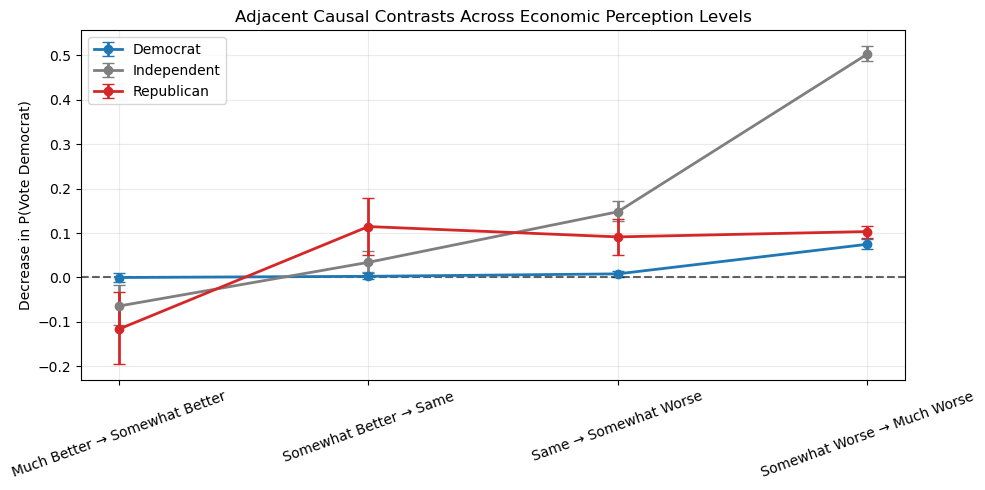

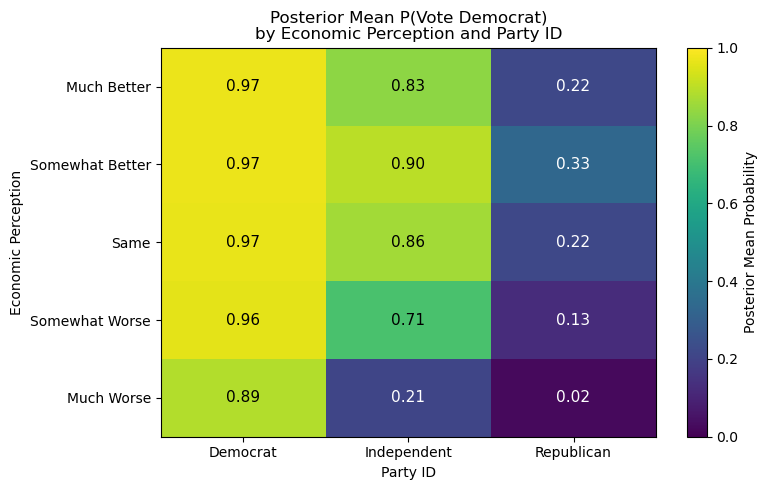

,estimand,mean,hdi_low,hdi_high,Pr(effect > 0)
0,P(V=1 | do(E=Much Better)) - P(V=1 | do(E=Much...,0.260381,0.238863,0.281861,1.0


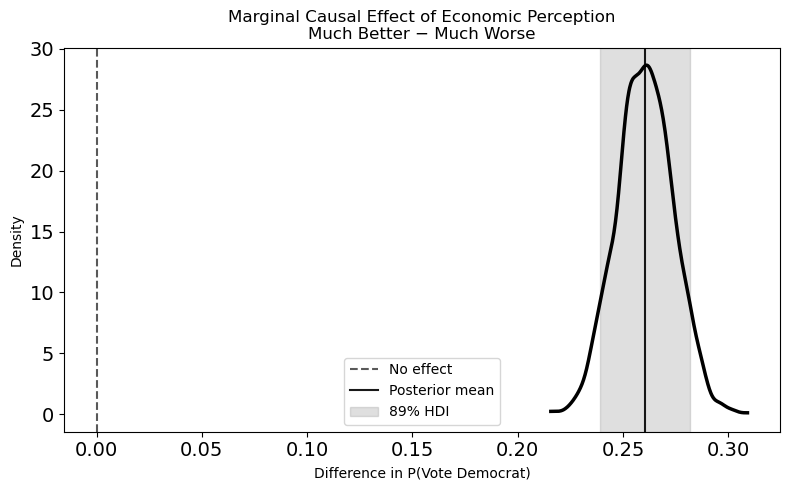

In [10]:
# ----------------------------
# Section 8: Final Causal Evidence Plots
# 1. Adjacent causal contrasts across economic perception levels
# 2. Heatmap of posterior mean probabilities
# 3. Marginal causal contrast / ATE
# ----------------------------

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from scipy.special import expit

az.rcParams["stats.hdi_prob"] = 0.89

# Extract posterior alpha samples
alpha_post = idata.posterior["alpha"].values
alpha_post = alpha_post.reshape(-1, alpha_post.shape[-2], alpha_post.shape[-1])

# Convert log-odds to probabilities
p_post = expit(alpha_post)  # samples x econ x party

party_colors = {
    "Democrat": "#1f77b4",
    "Independent": "#7f7f7f",
    "Republican": "#d62728"
}

# ============================================================
# 1. Adjacent causal contrasts across economic perception levels
# Contrast = P(V=1 | better econ level, P) - P(V=1 | worse econ level, P)
# ============================================================

adjacent_rows = []

for p_idx, party in enumerate(PARTY_LEVELS):
    for e_idx in range(len(ECON_LEVELS) - 1):

        contrast_draws = p_post[:, e_idx, p_idx] - p_post[:, e_idx + 1, p_idx]
        hdi = az.hdi(contrast_draws, hdi_prob=0.89)

        adjacent_rows.append({
            "party": party,
            "contrast": f"{ECON_LEVELS[e_idx]} - {ECON_LEVELS[e_idx + 1]}",
            "step": e_idx + 1,
            "mean": contrast_draws.mean(),
            "hdi_low": hdi[0],
            "hdi_high": hdi[1],
            "Pr(contrast > 0)": (contrast_draws > 0).mean()
        })

adjacent_df = pd.DataFrame(adjacent_rows)
display(adjacent_df)

fig, ax = plt.subplots(figsize=(10, 5))

for party in PARTY_LEVELS:
    temp = adjacent_df[adjacent_df["party"] == party]

    x = temp["step"].values
    y = temp["mean"].values

    yerr = np.vstack([
        y - temp["hdi_low"].values,
        temp["hdi_high"].values - y
    ])

    ax.errorbar(
        x,
        y,
        yerr=yerr,
        marker="o",
        linewidth=2,
        capsize=4,
        color=party_colors[party],
        label=party
    )

ax.axhline(0, linestyle="--", color="black", alpha=0.6)

ax.set_xticks([1, 2, 3, 4])
ax.set_xticklabels([
    "Much Better → Somewhat Better",
    "Somewhat Better → Same",
    "Same → Somewhat Worse",
    "Somewhat Worse → Much Worse"
], rotation=20)

ax.set_ylabel("Decrease in P(Vote Democrat)")
ax.set_title("Adjacent Causal Contrasts Across Economic Perception Levels")
ax.grid(alpha=0.25)
ax.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 2. Heatmap of posterior mean probabilities
# ============================================================

mean_probs = p_post.mean(axis=0)  # econ x party

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(
    mean_probs,
    aspect="auto",
    vmin=0,
    vmax=1
)

ax.set_xticks(np.arange(len(PARTY_LEVELS)))
ax.set_xticklabels(PARTY_LEVELS)

ax.set_yticks(np.arange(len(ECON_LEVELS)))
ax.set_yticklabels(ECON_LEVELS)

for e in range(len(ECON_LEVELS)):
    for p in range(len(PARTY_LEVELS)):
        value = mean_probs[e, p]
        ax.text(
            p,
            e,
            f"{value:.2f}",
            ha="center",
            va="center",
            color="white" if value < 0.45 else "black",
            fontsize=11
        )

ax.set_title("Posterior Mean P(Vote Democrat)\nby Economic Perception and Party ID")
ax.set_xlabel("Party ID")
ax.set_ylabel("Economic Perception")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Posterior Mean Probability")

plt.tight_layout()
plt.show()


# ============================================================
# 3. Marginal causal contrast / ATE
# P(V=1 | do(E=Much Better)) - P(V=1 | do(E=Much Worse))
# averaged over empirical party distribution
# ============================================================

party_weights = (
    df["party_id"]
    .value_counts(normalize=True)
    .reindex(PARTY_LEVELS)
    .values
)

much_better_idx = ECON_LEVELS.index("Much Better")
much_worse_idx = ECON_LEVELS.index("Much Worse")

p_much_better = np.sum(
    p_post[:, much_better_idx, :] * party_weights,
    axis=1
)

p_much_worse = np.sum(
    p_post[:, much_worse_idx, :] * party_weights,
    axis=1
)

ate_draws = p_much_better - p_much_worse
ate_hdi = az.hdi(ate_draws, hdi_prob=0.89)

ate_summary = pd.DataFrame({
    "estimand": ["P(V=1 | do(E=Much Better)) - P(V=1 | do(E=Much Worse))"],
    "mean": [ate_draws.mean()],
    "hdi_low": [ate_hdi[0]],
    "hdi_high": [ate_hdi[1]],
    "Pr(effect > 0)": [(ate_draws > 0).mean()]
})

display(ate_summary)

fig, ax = plt.subplots(figsize=(8, 5))

az.plot_kde(
    ate_draws,
    ax=ax,
    plot_kwargs={
        "color": "black",
        "linewidth": 2.5
    }
)

ax.axvline(0, linestyle="--", color="black", alpha=0.65, label="No effect")
ax.axvline(ate_draws.mean(), linestyle="-", color="black", alpha=0.9, label="Posterior mean")

ax.axvspan(
    ate_hdi[0],
    ate_hdi[1],
    color="gray",
    alpha=0.25,
    label="89% HDI"
)

ax.set_title("Marginal Causal Effect of Economic Perception\nMuch Better − Much Worse")
ax.set_xlabel("Difference in P(Vote Democrat)")
ax.set_ylabel("Density")
ax.legend()

plt.tight_layout()
plt.show()

## 9. Future Work

One limitation of our model is that it only includes economic perception and party identification. While party ID is the key confounder, voter behavior is also shaped by many other variables that we do not include, such as age, race, education, income, gender, ideology, media consumption, state/district context, and candidate quality. Including these variables could help us better separate the effect of economic perception from broader demographic and political patterns.

Another limitation is that we treat economic perception as the main driver of incumbent voting, but voters may also be responding to other national political factors. For example, the 2022 midterm elections were influenced not only by inflation and economic uncertainty, but also by opinions about President Biden, reactions to Donald Trump’s previous term, abortion politics after Dobbs, crime, immigration, and general polarization. These factors could affect both how voters evaluate the economy and how they vote.

Future work could expand the model by including additional confounders and predictors, especially ideology, approval of Biden, approval of Trump, demographic variables, and issue priorities. It would also be useful to compare national economic perception with personal economic perception to see whether voters respond more strongly to their own financial situation or to national conditions. Finally, future analysis could examine whether the economic perception effect varies by subgroup, such as Independents, swing-state voters, income groups, or education levels. This would help determine where economic voting is strongest and whether it mainly affects persuadable voters rather than strong partisans.

## 10. Group Member Contributions

* Proposal: Akarsh Malik, Harshal Pimpalshende, Shyamak Danavale
* Introduction: Akarsh Malik, Shyamak Danavale
* Causal Model: Akarsh Malik, Harshal Pimpalshende
* Statistical Model: Harshal Pimpalshende
* Model Validation on Simulated Data: Akarsh Malik, Harshal Pimpalshende
* Data Preparation: Akarsh Malik, Shyamak Danavale
* Posterior Model (Analysis on Real Data): Harshal Pimpalshende, Shyamak Danavale
* Posterior Predictive Checks: Akarsh Malik, Harshal Pimpalshende
* Discussion and Conclusion: Akarsh Malik, Shyamak Danavale
* Future Work: Akarsh Malik, Harshal Pimpalshende, Shyamak Danavale
